<a href="https://colab.research.google.com/github/Cal-Zayn/Tugas-Fundamen-sains-data/blob/main/Fundamen%20sains%20data%201.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install numpy

In [ ]:
import numpy as np

# Example usage
array = np.array([1, 2, 3, 4, 5])
print(array)

[1 2 3 4 5]


Similarly, to install scikit-learn, you would run:

In [ ]:
!pip install scikit-learn

In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/laptop_price - dataset.csv')

# Display the first 5 rows of the DataFrame
display(df.head())

,Company,Product,TypeName,Inches,ScreenResolution,CPU_Company,CPU_Type,CPU_Frequency (GHz),RAM (GB),Memory,GPU_Company,GPU_Type,OpSys,Weight (kg),Price (Euro)
0,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,2.3,8,128GB SSD,Intel,Iris Plus Graphics 640,macOS,1.37,1339.69
1,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel,Core i5,1.8,8,128GB Flash Storage,Intel,HD Graphics 6000,macOS,1.34,898.94
2,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel,Core i5 7200U,2.5,8,256GB SSD,Intel,HD Graphics 620,No OS,1.86,575.00
3,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel,Core i7,2.7,16,512GB SSD,AMD,Radeon Pro 455,macOS,1.83,2537.45
4,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,3.1,8,256GB SSD,Intel,Iris Plus Graphics 650,macOS,1.37,1803.60


In [ ]:
# Display column information and data types
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1275 entries, 0 to 1274
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Company              1275 non-null   object 
 1   Product              1275 non-null   object 
 2   TypeName             1275 non-null   object 
 3   Inches               1275 non-null   float64
 4   ScreenResolution     1275 non-null   object 
 5   CPU_Company          1275 non-null   object 
 6   CPU_Type             1275 non-null   object 
 7   CPU_Frequency (GHz)  1275 non-null   float64
 8   RAM (GB)             1275 non-null   int64  
 9   Memory               1275 non-null   object 
 10  GPU_Company          1275 non-null   object 
 11  GPU_Type             1275 non-null   object 
 12  OpSys                1275 non-null   object 
 13  Weight (kg)          1275 non-null   float64
 14  Price (Euro)         1275 non-null   float64
dtypes: float64(4), int64(1), object(10)
me

None

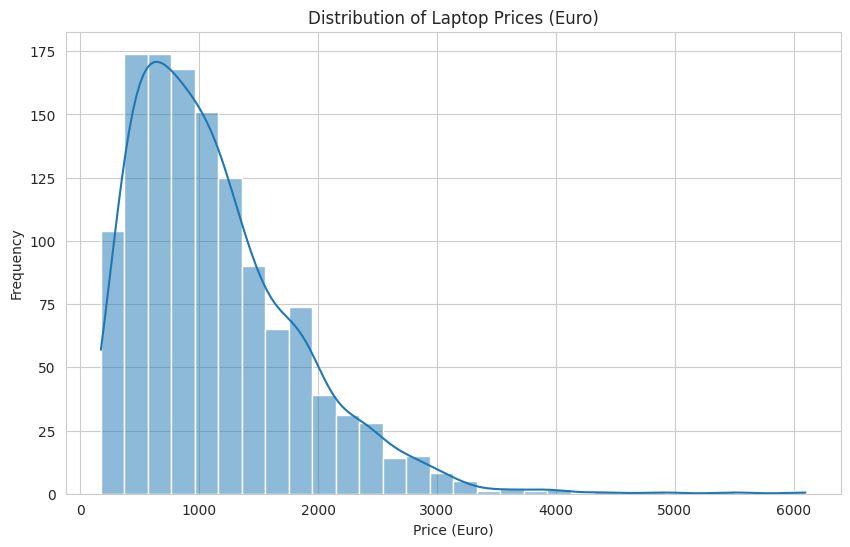

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))
sns.histplot(df['Price (Euro)'], kde=True, bins=30)
plt.title('Distribution of Laptop Prices (Euro)')
plt.xlabel('Price (Euro)')
plt.ylabel('Frequency')
plt.show()

Mari kita lihat hubungan antara 'Price (Euro)' dengan beberapa fitur numerik seperti RAM dan berat.

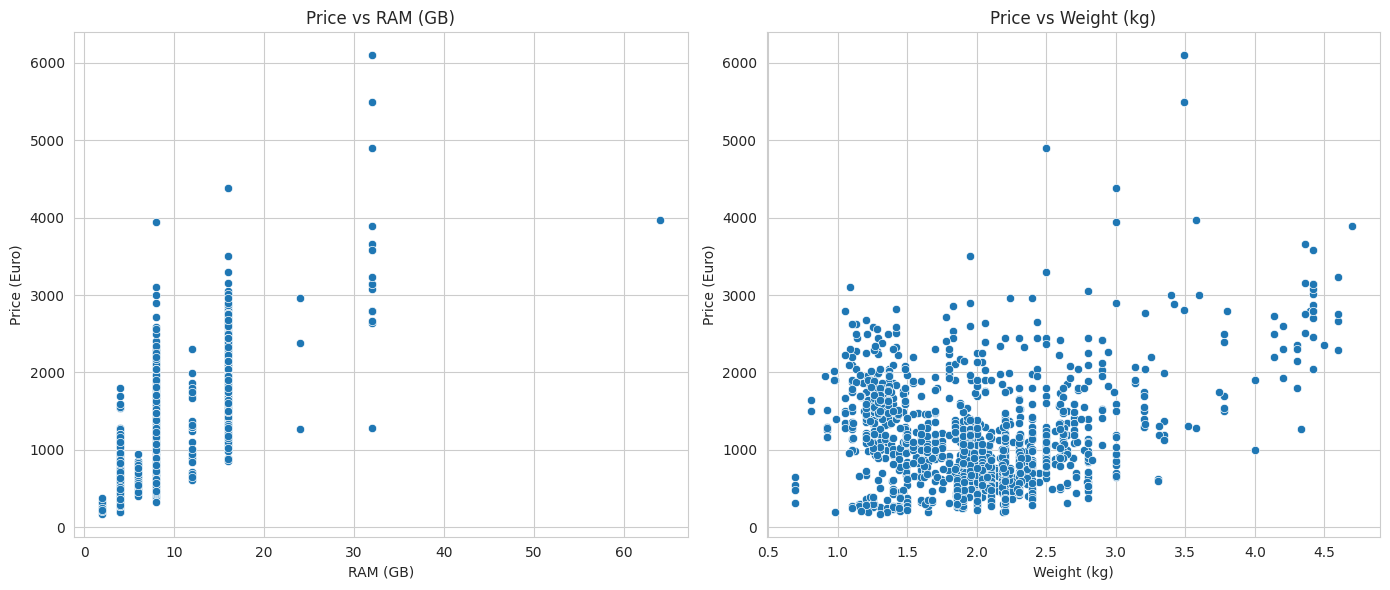

In [ ]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
sns.scatterplot(x='RAM (GB)', y='Price (Euro)', data=df)
plt.title('Price vs RAM (GB)')
plt.xlabel('RAM (GB)')
plt.ylabel('Price (Euro)')

plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
sns.scatterplot(x='Weight (kg)', y='Price (Euro)', data=df)
plt.title('Price vs Weight (kg)')
plt.xlabel('Weight (kg)')
plt.ylabel('Price (Euro)')

plt.tight_layout()
plt.show()

Sekarang, mari kita analisis hubungan harga dengan beberapa fitur kategorikal seperti 'Company' (Produsen) dan 'TypeName' (Jenis Laptop).

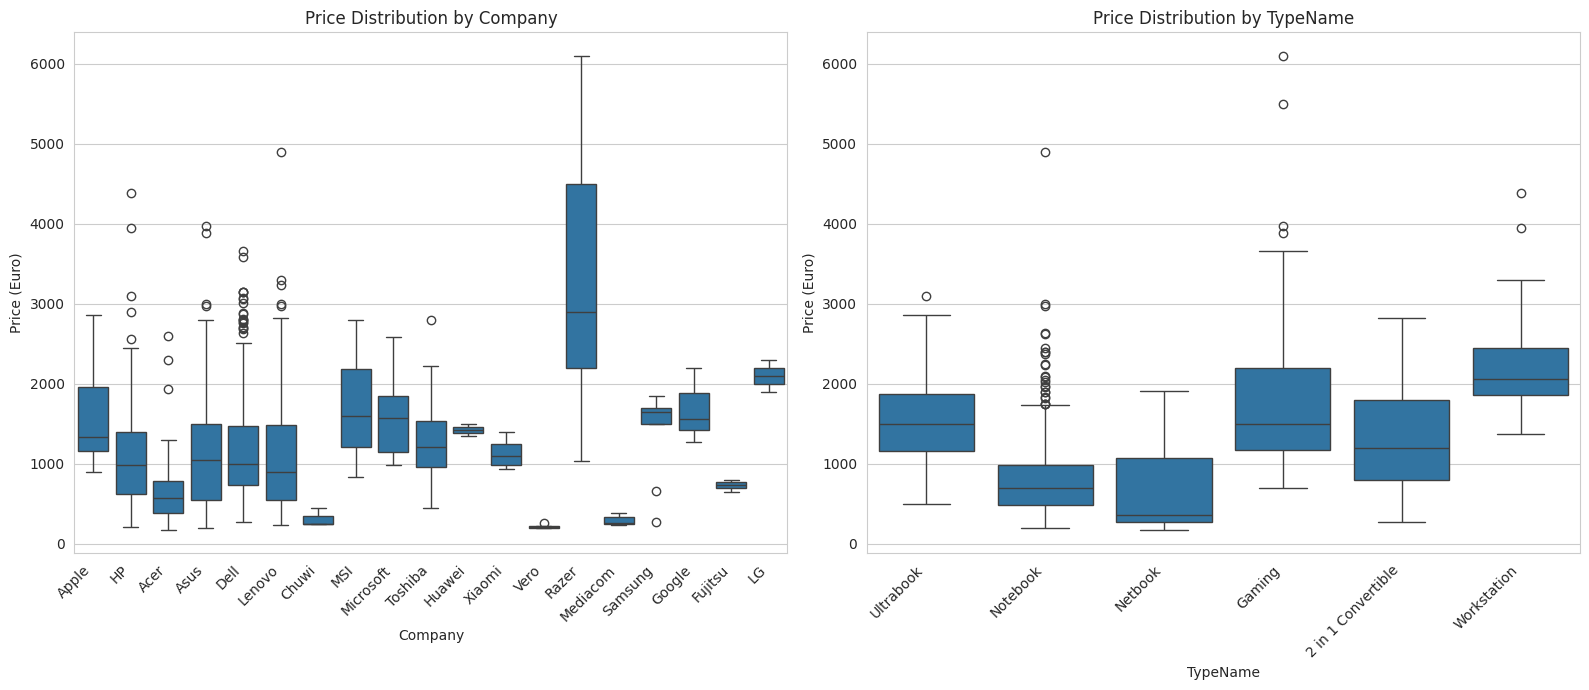

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 7))

plt.subplot(1, 2, 1)
sns.boxplot(x='Company', y='Price (Euro)', data=df)
plt.title('Price Distribution by Company')
plt.xlabel('Company')
plt.ylabel('Price (Euro)')
plt.xticks(rotation=45, ha='right')

plt.subplot(1, 2, 2)
sns.boxplot(x='TypeName', y='Price (Euro)', data=df)
plt.title('Price Distribution by TypeName')
plt.xlabel('TypeName')
plt.ylabel('Price (Euro)')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

## Data Preparation for Linear Regression

Sebelum melatih model, kita perlu menyiapkan data:
1.  **Feature Selection**: Memilih fitur yang relevan (variabel independen) dan variabel target.
2.  **Categorical Feature Encoding**: Mengubah fitur kategorikal menjadi format numerik yang dapat dipahami model (misalnya, menggunakan One-Hot Encoding).
3.  **Data Splitting**: Memisahkan data menjadi set pelatihan dan pengujian untuk mengevaluasi kinerja model.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd

# 1. Feature Selection
# Memilih fitur numerik dan beberapa fitur kategorikal yang relevan.
# 'Company', 'TypeName', 'ScreenResolution', 'OpSys', 'GPU_Company', 'CPU_Company'

features = ['Inches', 'RAM (GB)', 'CPU_Frequency (GHz)', 'Weight (kg)',
            'Company', 'TypeName', 'ScreenResolution', 'OpSys', 'GPU_Company', 'CPU_Company']
target = 'Price (Euro)'

X = df[features]
y = df[target]

# Handle categorical features using one-hot encoding
X = pd.get_dummies(X, columns=['Company', 'TypeName', 'ScreenResolution', 'OpSys', 'GPU_Company', 'CPU_Company'], drop_first=True)

# 2. Data Splitting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (1020, 79)
Shape of X_test: (255, 79)
Shape of y_train: (1020,)
Shape of y_test: (255,)


## Model Training: Linear Regression

Sekarang, kita akan melatih model `LinearRegression` menggunakan data pelatihan yang telah kita siapkan.

In [ ]:
# Inisialisasi dan latih model Linear Regression
model = LinearRegression()
model.fit(X_train, y_train)

print("Model Linear Regression telah berhasil dilatih.")

Model Linear Regression telah berhasil dilatih.


## Model Evaluation

Setelah model dilatih, penting untuk mengevaluasi kinerjanya pada data yang belum pernah dilihat sebelumnya (data pengujian). Kita akan menggunakan metrik berikut:
*   **Mean Absolute Error (MAE)**: Rata-rata dari nilai absolut semua kesalahan. Ini memberikan ukuran seberapa dekat prediksi model dengan hasil aktual, di mana semua kesalahan ditimbang sama.
*   **Mean Squared Error (MSE)**: Rata-rata dari kuadrat semua kesalahan. Ini lebih sensitif terhadap kesalahan besar dibandingkan MAE.
*   **R-squared (R2 Score)**: Mengukur proporsi varians dalam variabel dependen yang dapat diprediksi dari variabel independen. Nilai 1 menunjukkan kecocokan sempurna, dan 0 menunjukkan bahwa model tidak menjelaskan varians target sama sekali.

In [ ]:
# Lakukan prediksi pada set pengujian
y_pred = model.predict(X_test)

# Evaluasi model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse**0.5 # Root Mean Squared Error
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2 Score): {r2:.2f}")

Mean Absolute Error (MAE): 258.33
Mean Squared Error (MSE): 122066.22
Root Mean Squared Error (RMSE): 349.38
R-squared (R2 Score): 0.75


## Koefisien Regresi (Slope) dan Intercept

Koefisien regresi menunjukkan seberapa besar perubahan variabel dependen (harga) ketika salah satu variabel independen berubah satu unit, dengan asumsi variabel independen lainnya konstan. Intercept adalah nilai variabel dependen ketika semua variabel independen bernilai nol.

In [ ]:
print("\n--- Koefisien Regresi (Slope) ---")
# Menampilkan koefisien untuk setiap fitur
# Pastikan urutan koefisien sesuai dengan urutan kolom di X_train
coef_df = pd.DataFrame({'Feature': X_train.columns, 'Coefficient': model.coef_})
display(coef_df)

print("\n--- Intercept ---")
print(f"Intercept: {model.intercept_:.2f}")


--- Koefisien Regresi (Slope) ---


,Feature,Coefficient
0,Inches,-54.968452
1,RAM (GB),59.098953
2,CPU_Frequency (GHz),166.386646
3,Weight (kg),219.388871
4,Company_Apple,340.959683
...,...,...
74,GPU_Company_ARM,53.805419
75,GPU_Company_Intel,140.897937
76,GPU_Company_Nvidia,117.680566
77,CPU_Company_Intel,174.133703



--- Intercept ---
Intercept: 147.44


## Visualisasi Prediksi Model vs. Data Aktual

Untuk lebih memahami kinerja model, mari kita visualisasikan nilai aktual (data pengujian) terhadap nilai yang diprediksi oleh model regresi linier. Plot ini akan menunjukkan seberapa dekat prediksi model dengan kenyataan.

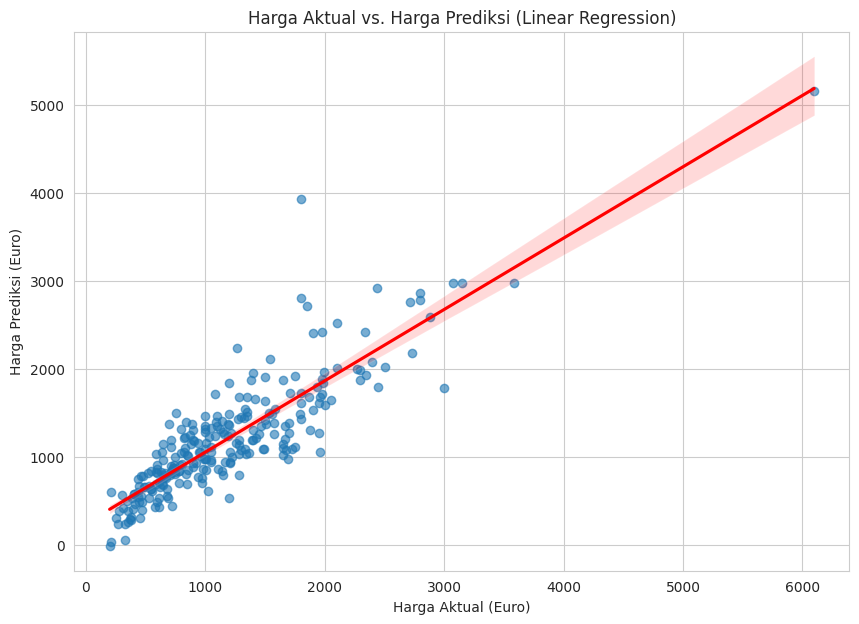

In [ ]:
plt.figure(figsize=(10, 7))
sns.regplot(x=y_test, y=y_pred, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.xlabel('Harga Aktual (Euro)')
plt.ylabel('Harga Prediksi (Euro)')
plt.title('Harga Aktual vs. Harga Prediksi (Linear Regression)')
plt.grid(True)
plt.show()

Plot regresi yang baru saja saya tampilkan (Harga Aktual vs. Harga Prediksi) berfungsi untuk membandingkan hasil prediksi model dengan nilai aktual. Pada plot tersebut:

Setiap titik mewakili satu laptop, dengan sumbu X adalah harga aktual dan sumbu Y adalah harga prediksi.
Garis merah adalah garis regresi ideal, di mana prediksi sama persis dengan nilai aktual.

Makna dari Slope (Koefisien Regresi) dan Intercept:
Slope (Koefisien Regresi): Setiap koefisien menunjukkan perubahan rata-rata pada harga laptop (variabel dependen) untuk setiap kenaikan satu unit pada fitur independen yang sesuai, dengan asumsi semua fitur independen lainnya tetap konstan. bold text Misalnya:

Jika koefisien untuk 'RAM (GB)' adalah 59.10, ini berarti setiap penambahan 1 GB RAM diasosiasikan dengan kenaikan harga sebesar 59.10 Euro, dengan asumsi faktor lain tidak berubah.

Koefisien negatif, seperti pada 'Inches' (-54.97), bisa berarti bahwa untuk laptop dengan spesifikasi lain yang serupa, ukuran layar yang lebih besar (dalam inci) justru diasosiasikan dengan harga yang sedikit lebih rendah, atau bisa juga karena fitur ini berinteraksi dengan fitur lain yang memiliki efek positif besar.
Untuk fitur kategorikal yang telah di-encode (misalnya Company_Apple), koefisiennya menunjukkan perbedaan harga rata-rata dibandingkan dengan kategori dasar (yang dihilangkan saat one-hot encoding, drop_first=True).
Intercept: Intercept adalah nilai prediksi harga laptop ketika semua fitur independen bernilai nol. Dalam kasus ini, nilai intercept adalah 147.44 Euro. Secara praktis, nilai ini mungkin tidak selalu memiliki interpretasi fisik yang realistis, terutama karena beberapa fitur (seperti 'RAM (GB)') tidak bisa bernilai nol dalam konteks laptop yang berfungsi.

Seberapa Baik Model Memprediksi Data?
R-squared (R2 Score): 0.75

Nilai R2 sebesar 0.75 berarti bahwa model kita dapat menjelaskan sekitar 75% variasi harga laptop dalam data pengujian. Ini menunjukkan bahwa 75% perubahan harga dapat dijelaskan oleh fitur-fitur yang kita gunakan dalam model. Angka ini cukup baik, menunjukkan bahwa model memiliki kemampuan prediksi yang layak.
Mean Absolute Error (MAE): 258.33

Rata-rata selisih absolut antara harga prediksi dan harga aktual adalah 258.33 Euro. Artinya, rata-rata, prediksi harga dari model kita meleset sekitar 258.33 Euro dari harga sebenarnya.
Root Mean Squared Error (RMSE): 349.38

RMSE sebesar 349.38 Euro memberikan indikasi besarnya kesalahan prediksi. RMSE lebih sensitif terhadap kesalahan besar dibandingkan MAE. Ini juga menunjukkan rata-rata besar kesalahan dalam satuan mata uang (Euro).
Secara keseluruhan, metrik ini menunjukkan bahwa model bekerja dengan cukup baik, mampu menangkap sebagian besar variasi harga dan membuat prediksi dengan tingkat kesalahan yang wajar.

Indikasi Overfitting atau Underfitting?
Overfitting terjadi ketika model belajar terlalu banyak detail dan noise dari data pelatihan sehingga kinerjanya buruk pada data baru/pengujian. Underfitting terjadi ketika model terlalu sederhana dan tidak mampu menangkap pola dasar dalam data.

Berdasarkan hasil saat ini:

R2 Score (0.75) yang cukup tinggi menunjukkan bahwa model tidak underfit secara signifikan, karena mampu menjelaskan sebagian besar variasi.
Plot regresi 'Harga Aktual vs. Harga Prediksi' menunjukkan titik-titik data yang cukup tersebar di sekitar garis regresi. Jika titik-titik ini terlalu jauh, itu bisa menunjukkan underfitting. Jika titik-titik ini terlihat terlalu 'pas' dengan sedikit deviasi, itu bisa mengindikasikan overfitting.
Tanpa membandingkan kinerja model pada data pelatihan dan data pengujian secara eksplisit (misalnya, R2 pada y_train vs y_test), sulit untuk membuat kesimpulan definitif tentang overfitting. Namun, karena kita menggunakan train_test_split dan mendapatkan R2 yang layak pada X_test, ada indikasi bahwa model cukup generalizable dan tidak terlalu overfit.